<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/excercice_model_fitting_and_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Uncertainty - modelling and slection**

This Colab notebook provides an introduction to uncertainty modeling, covering aleatoric models and an introduction to model selection.  

**THE STUDENTS WILL**:
1. Generate n=1000 data points using the DGM provided
2. Explore the data (plot it, print mean, standard deviation)
3. Fit a (parametric) GMM model and a (non-parametric) KDE model
4. Repeat the GMM fitting for a list of [2, 10, 15, 20, 60, 80] components. compare likelihood, BIC, and AIC.
5. Same for the KDE different bandwidth. 6. Visualization + discussion on the best model


## 🎯 **Data Generation Mechanism (DGM)**  

Before working with probabilistic models, we need some data.

We will start with two synthetic datasets.  

### 🔹 `data_generation_mechanism()` function  
This function simulates an experiment where samples are drawn and datasets generated.

We have three different sampling mechanisms:  

1️⃣ **Normal Distribution** – Generates Gaussian-distributed data.  
2️⃣ **Blobs (Clusters of Points)** – Useful for classification tasks.  
3️⃣ **Two Moons Dataset** – A non-linearly separable dataset often used for clustering.   

---

In [1]:
# Here we import useful packages and methods
# math and statistical tools
import numpy as np
import math
import scipy.stats as stats
import numpy.random as random

# tools for visualization and plotting
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn as skl
from sklearn.datasets import make_blobs, make_moons
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

In [2]:
def data_generation_mechanism(n_samples: int = 100,
                              n_dimensions: int = 1,
                              type='normal',
                              add_noise: bool = False,
                              nose_level: float = 0.5):
    """
    Generates a matrix of random data with specified number of samples and dimensions.

    Parameters:
    - n_samples (int): Number of samples (rows of the matrix).
    - n_dimensions (int): Number of dimensions (columns of the matrix).
    - type (str): The type of data distribution ('normal', 'blobs', 'two_moons').

    Returns:
    - np.ndarray: A matrix with shape (n_samples, n_dimensions), filled with random data.
    """
    # Default to 'normal' if no type is specified
    if type is None:
        type = 'normal'

    if type == 'normal':
        # For normal distribution, we use a multivariate normal distribution
        mean = [0] * n_dimensions  # Mean vector
        cov = np.eye(n_dimensions)  # Identity covariance matrix (no correlation)
        data_matrix = np.random.multivariate_normal(mean, cov, size=n_samples)

    elif type == 'blobs':
        # Generate data from blobs (clusters of points)
        data_matrix, _ = make_blobs(n_samples=n_samples, n_features=n_dimensions, random_state=42)

    elif type == 'two_moons':
        # Generate two moons dataset (non-linear)
        data_matrix, _ = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

    else:
        raise ValueError(f"Unsupported data type: {type}")

    if add_noise:
        # Add Gaussian noise to the data
        noise = np.random.normal(0, nose_level, size=(n_samples, n_dimensions))
        data_matrix += noise

    return data_matrix


## 🔬 **Data Visualization Examples**  

We generate and visualize different datasets using:  
- **Clusters of points (blobs)**  
- **Two moons dataset** (with and without noise)  

Additionally, we explore the effect of different **noise levels** on data distribution.  



In [6]:
# Data Generation Mechanism:
# Data Generation Mechanism:
n_samples = 1000  # Number of samples
n_dimensions = 2  # Number of dimensions
data_blobs = data_generation_mechanism(n_samples, n_dimensions, type='blobs')      # Generate data of type 'blobs'
data_moons = data_generation_mechanism(n_samples, n_dimensions, type='two_moons', add_noise=False)

### 📊 **Plots Included**  
✔️ Scatter plots of generated data  
✔️ Effect of noise on the two moons dataset     

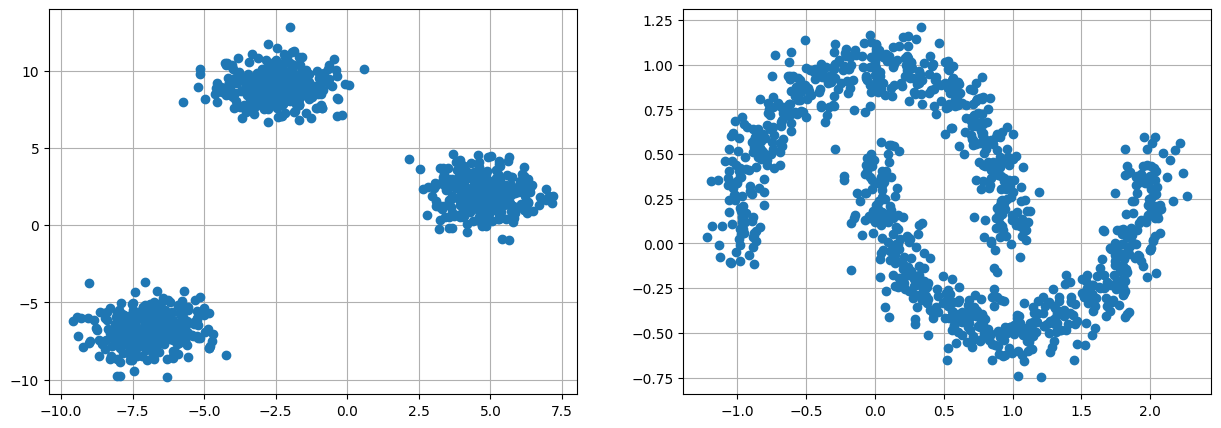

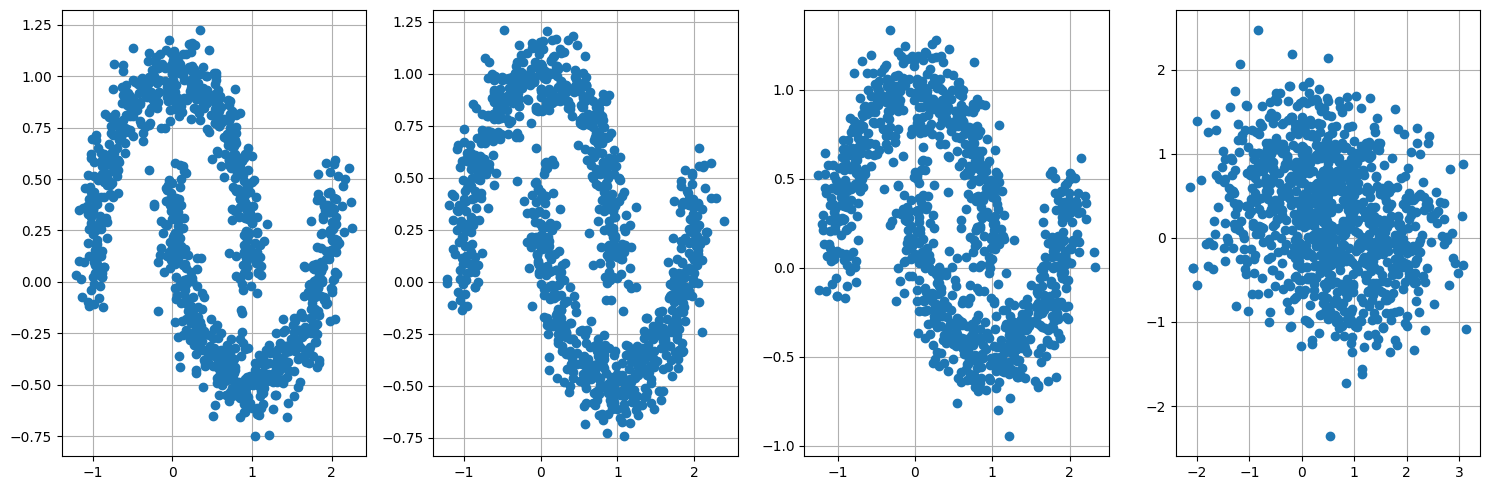

In [9]:
# Scatter plot visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(data_blobs[:, 0], data_blobs[:, 1], 'o', label='blobs')
ax[1].plot(data_moons[:, 0], data_moons[:, 1], 'o', label='two_moons')
ax[0].grid()
ax[1].grid()
plt.show()


# Generating mechanism + additional noise
noise_levels = [0.01, 0.05, 0.1, 0.5]
fig, axs = plt.subplots(1, len(noise_levels), figsize=(15, 5))
for noise_level, ax in zip(noise_levels, axs):
    data_moons_noise = data_generation_mechanism(n_samples, n_dimensions, type='two_moons', add_noise=True, nose_level=noise_level)
    ax.plot(data_moons_noise[:, 0], data_moons_noise[:, 1], 'o', label=f'two_moons (noise={noise_level})')
    ax.grid()
plt.tight_layout()
plt.show()


## **Fitting, visualization & comparison of models**:

**Raw Data:** Displays the actual points generated from the "Two Moons" dataset, which may have non-linear separability.

**GMM PDF:** Fit and visualize how well the Gaussian Mixture Model (GMM) approximates the underlying data distribution with $M=2$ Gaussian components.

```
M = 2 # two gaussian mixtures
GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
GMM.fit(data) # fit the model
```

**KDE Density:** Fit and visualize how well the Kernel Density Estimator (KDE) approximates the underlying data distribution with a bandwidth $h=10$

```
  h = 10
  kde = KernelDensity(kernel='gaussian', bandwidth=h)
  kde.fit(data)
```
**COMPUTE THE LOG-LIKELIHOOD PER SAMPLE**



**NOTE:**

1️⃣ `score_samples(DATA)`

Returns the log-density evaluated at each sample:
$\log f(u^{(i)})  $

2️⃣ `score(DATA)`
Returns the average log-likelihood of the data under the model:
$\frac{1}{N} \sum_{i=1}^N \log f(u^{(i)})  $


Log-Lik GMM with M=2 component:  -1745.5639713394296
Log-Lik KDE with h=10.0 bandwith :  -6453.134918441316


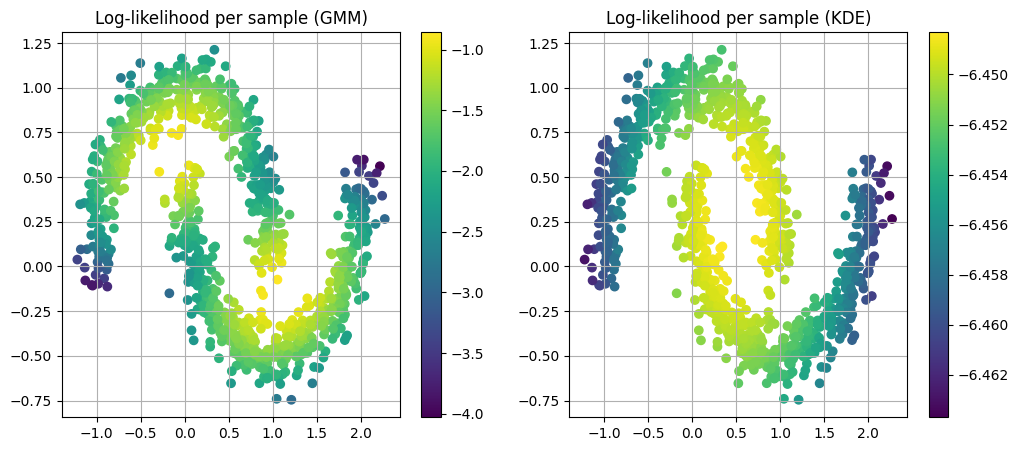

In [60]:
#  data = data_blobs  # select the data you wish to explore
data = data_moons

M = 2 # two gaussian mixtures for the GMM model
GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
GMM.fit(data) # fit the model

h = 10.0 # smoothing parameter for the KDE model
KDE = KernelDensity(kernel='gaussian', bandwidth=h)
KDE.fit(data)

# Evaluate log-likelihood per sample and total
def evaluate_log_likelihood(GMM, KDE, data):
  LL_GMM_per_sample = GMM.score_samples(data)
  LL_KDE_per_sample = KDE.score_samples(data)
  LL_GMM = np.sum(LL_GMM_per_sample)
  LL_KDE = np.sum(LL_KDE_per_sample)
  print(f'Log-Lik GMM with M={M} component: ', LL_GMM)
  print(f'Log-Lik KDE with h={h} bandwith : ', LL_KDE)
  return LL_GMM_per_sample, LL_KDE_per_sample, LL_GMM, LL_KDE

# apply logliklihood method, print log-lik scores
LL_GMM_per_sample, LL_KDE_per_sample, LL_GMM, LL_KDE = evaluate_log_likelihood(GMM, KDE, data)


# VISUALIZATION
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)# GMM likelihood
plt.scatter(data[:,0], data[:,1], c=LL_GMM_per_sample, cmap='viridis')
plt.title("Log-likelihood per sample (GMM)")
plt.colorbar()  # add colorbar likelihood value individual samples
plt.grid()  # add grid better visual
plt.subplot(1,2,2)# KDE likelihood
plt.scatter(data[:,0], data[:,1], c=LL_KDE_per_sample, cmap='viridis')
plt.title("Log-likelihood per sample (KDE)")
plt.colorbar()
plt.grid()
plt.show()




**Iso-Probability Curves:** Helps compare how GMM and KDE models capture data distributions and their density levels.


```
  # Create a mesh grid for density visualization
  n_grid_points=200
  x = np.linspace(min(data[:, 0])-1, max(data[:, 0])+1, n_grid_points)
  y = np.linspace(min(data[:, 1])-1, max(data[:, 1])+1, n_grid_points)
  X, Y = np.meshgrid(x, y)
  grid_points = np.column_stack([X.ravel(), Y.ravel()])

  # Evaluate densities
  log_likelihood = model.score_samples(grid_points)
  pdf_density = np.exp(log_likelihood).reshape(X.shape)
  # use the ax.contour(X, Y, pdf_density, levels=20, colors='blue', linestyles='solid') function

```



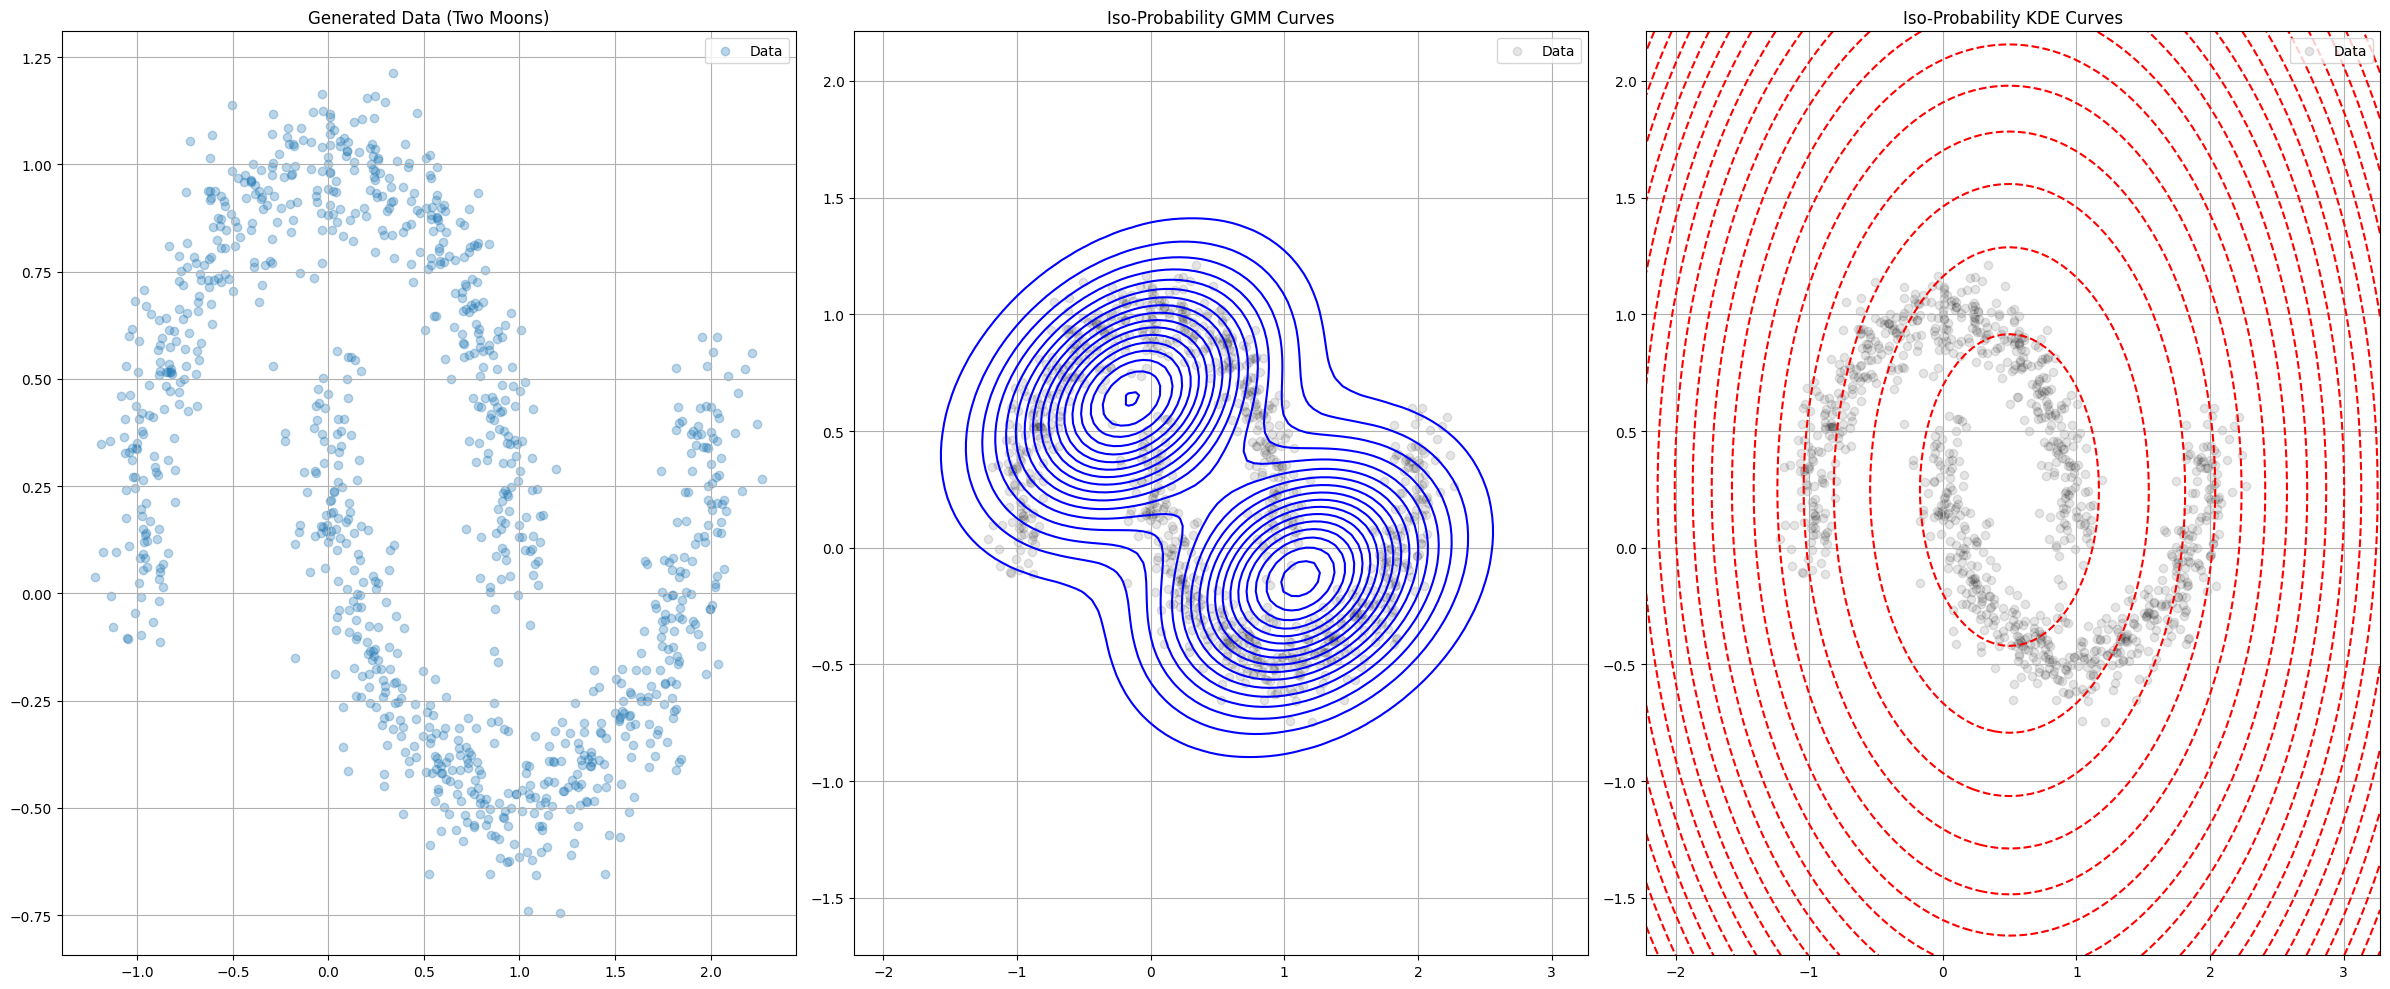

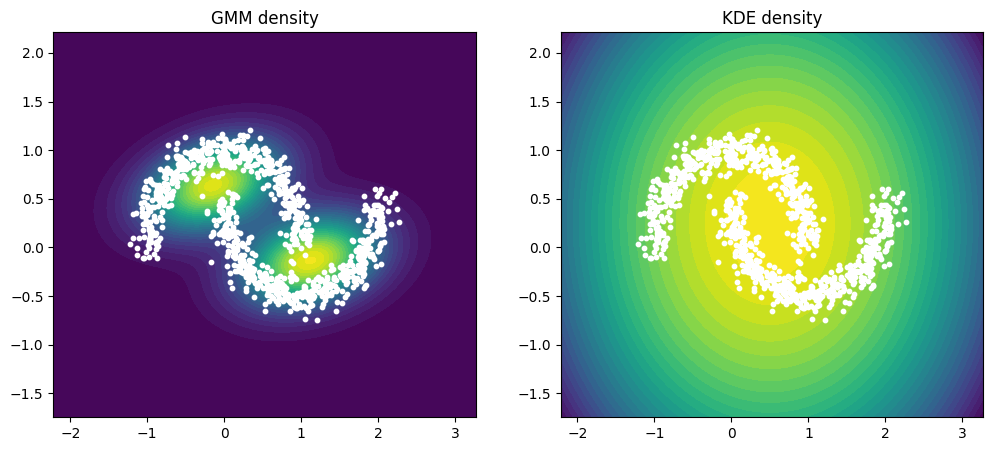

In [61]:
def plot_iso_probability_curves(GMM, KDE, data, n_grid_points=100):
  # simple function to show iso-probabilty curves of the two model
  x = np.linspace(min(data[:, 0])-1, max(data[:, 0])+1, n_grid_points)
  y = np.linspace(min(data[:, 1])-1, max(data[:, 1])+1, n_grid_points)
  X, Y = np.meshgrid(x, y)
  grid_points = np.column_stack([X.ravel(), Y.ravel()])

  # Evaluate densities (PDF values)
  gmm_density = np.exp(GMM.score_samples(grid_points)).reshape(X.shape)
  kde_density = np.exp(KDE.score_samples(grid_points)).reshape(X.shape)

  # Visualize results
  fig, ax = plt.subplots(1, 3, figsize=(24, 10))

  # Raw data
  ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, label="Data")
  ax[0].set_title("Generated Data (Two Moons)")
  ax[0].legend()

  # Iso-probability density curves
  ax[1].contour(X, Y, gmm_density, levels=20, colors='blue', linestyles='solid')
  ax[2].contour(X, Y, kde_density, levels=20, colors='red', linestyles='dashed')
  ax[1].scatter(data[:, 0], data[:, 1], alpha=0.1, color="black", label="Data")
  ax[2].scatter(data[:, 0], data[:, 1], alpha=0.1, color="black", label="Data")
  ax[1].set_title("Iso-Probability GMM Curves")
  ax[2].set_title("Iso-Probability KDE Curves")
  ax[2].legend()
  ax[1].legend()

  [a.grid() for a in ax]
  plt.tight_layout()
  plt.show()


  # alternative visualization
  xx, yy = np.meshgrid(
      np.linspace(data[:,0].min()-1, data[:,0].max()+1, 200),
      np.linspace(data[:,1].min()-1, data[:,1].max()+1, 200)
  )

  grid = np.c_[xx.ravel(), yy.ravel()]

  Z_gmm = np.exp(GMM.score_samples(grid)).reshape(xx.shape)
  Z_kde = np.exp(KDE.score_samples(grid)).reshape(xx.shape)

  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  plt.contourf(xx,yy,Z_gmm, levels=30)
  plt.scatter(data[:,0], data[:,1], s=10, c='white')
  plt.title("GMM density")

  plt.subplot(1,2,2)
  plt.contourf(xx,yy,Z_kde, levels=30)
  plt.scatter(data[:,0], data[:,1], s=10, c='white')
  plt.title("KDE density")

  plt.show()



# use it now
plot_iso_probability_curves(GMM, KDE, data)

## Visually we cal already tell these may be not very goodt models
## how can we **fit and select** a better model?

Log-Lik GMM with M=4 component:  -1327.7482172412128
Log-Lik KDE with h=0.5 bandwith :  -1998.3888942436224


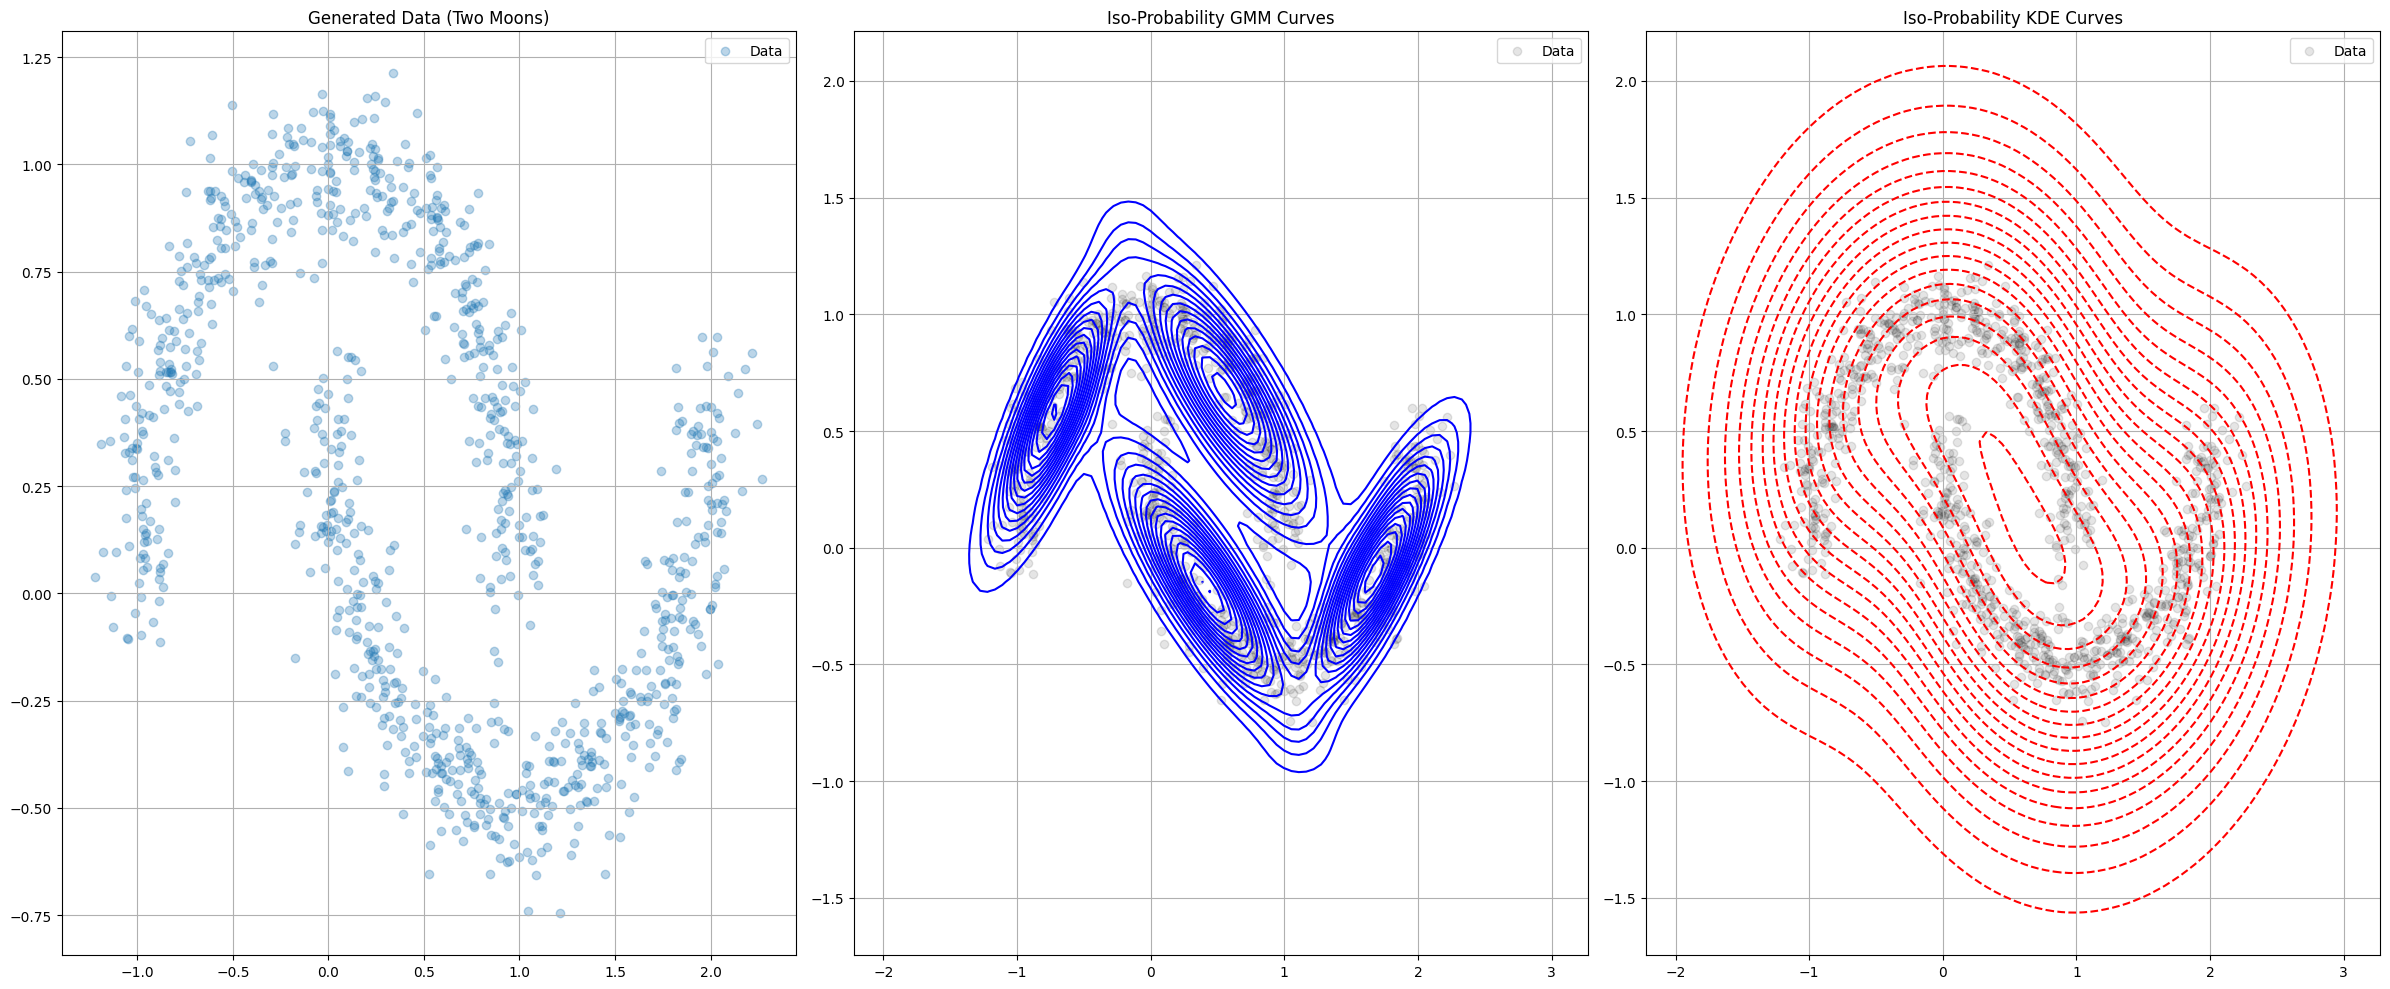

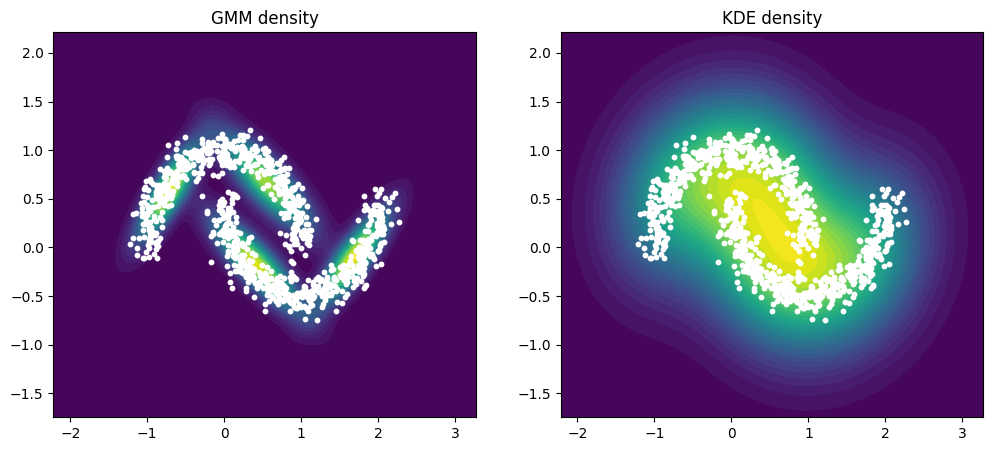

In [62]:
M = 4 # MORE MIXTURES -> MORE REPRESENTATRION POWER -> MORE COMPLEX -> RISK OVERFITTING
GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
GMM.fit(data) # fit the model

h = 0.5 # LOWER BANDWIDTH -> LESS SMOOTHING -> RISK OF OVERFITTING
KDE = KernelDensity(kernel='gaussian', bandwidth=h)
KDE.fit(data)

# apply logliklihood method, print log-lik scores
LL_GMM_per_sample, LL_KDE_per_sample, LL_GMM, LL_KDE = evaluate_log_likelihood(GMM, KDE, data)


#visualize
plot_iso_probability_curves(GMM, KDE, data)




**Model selection:** Compare AIC, BIC, and likelihood of different models. Select a list of bandwidths (KDE) and list with a number of mixtures (GMM), repeat the fitting, evaluate goodness of fit vs complexity.


```
  kde.aic(data) # on fitted model
  kde.bic(data)
```

Log-Lik GMM with M=2 component:  -1745.5639713394296
AIC score ofthe GMM with M=2 component:  3513.127942678859
BIC score ofthe GMM with M=2 component:  3567.1132507476627
Log-Lik GMM with M=3 component:  -1512.1548811986268
AIC score ofthe GMM with M=3 component:  3058.3097623972535
BIC score ofthe GMM with M=3 component:  3141.74160213995
Log-Lik GMM with M=4 component:  -1327.7482172412128
AIC score ofthe GMM with M=4 component:  2701.4964344824257
BIC score ofthe GMM with M=4 component:  2814.374805899015
Log-Lik GMM with M=5 component:  -1219.2198237811713
AIC score ofthe GMM with M=5 component:  2496.4396475623425
BIC score ofthe GMM with M=5 component:  2638.7645506528247
Log-Lik GMM with M=6 component:  -1081.902243696658
AIC score ofthe GMM with M=6 component:  2233.804487393316
BIC score ofthe GMM with M=6 component:  2405.5759221576905
Log-Lik GMM with M=7 component:  -1037.2095779898768
AIC score ofthe GMM with M=7 component:  2156.4191559797537
BIC score ofthe GMM with M=7

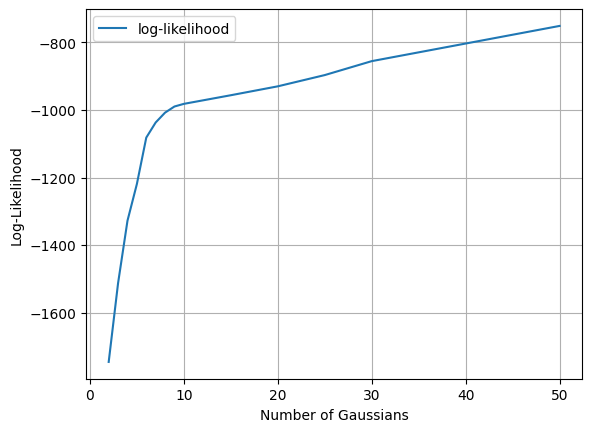

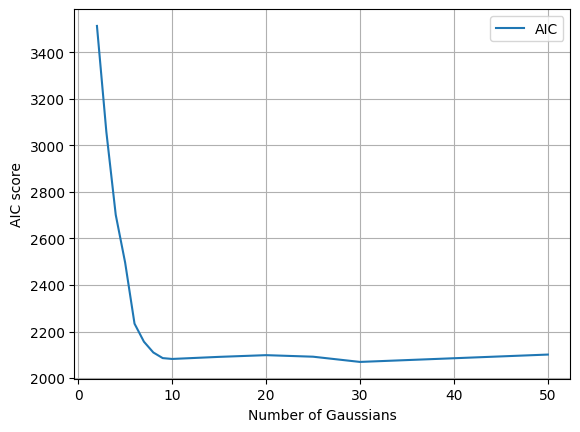

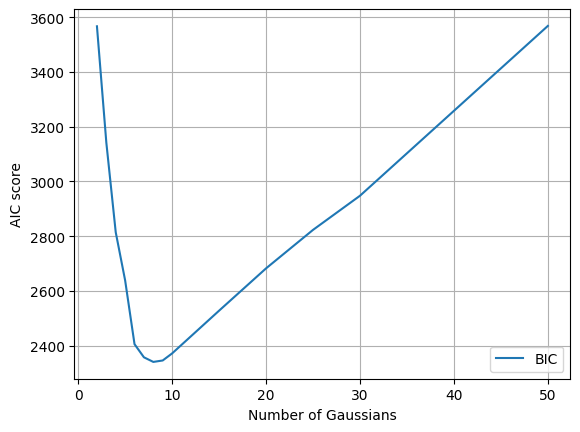

In [75]:
AIC_list =[]
BIC_list = []
LL_list = []

# print log-likelihood
number_of_gaussians_list = [2,3,4,5,6,7,8,9,10,15,20,25,30,50]
for M in number_of_gaussians_list:

  GMM = GaussianMixture(n_components=M, covariance_type='full', random_state=42)
  GMM.fit(data) # fit the GMM model


  LL = np.sum(GMM.score_samples(data) ) # Log-Likelihood
  AIC = GMM.aic(data) # AIC score
  BIC = GMM.bic(data) # BIC score

  LL_list.append(LL)
  AIC_list.append(AIC)
  BIC_list.append(BIC)

  print(f'Log-Lik GMM with M={M} component: ', LL)
  print(f'AIC score of the GMM with M={M} component: ', AIC)
  print(f'BIC score of the GMM with M={M} component: ', BIC)

plt.plot(number_of_gaussians_list, LL_list, label='log-likelihood')
plt.xlabel('Number of Gaussians (GMM)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.grid()
plt.show()

plt.plot(number_of_gaussians_list, AIC_list, label='AIC')
plt.xlabel('Number of Gaussians (GMM)')
plt.ylabel('AIC score')
plt.legend()
plt.grid()
plt.show()


plt.plot(number_of_gaussians_list, BIC_list, label='BIC')
plt.xlabel('Number of Gaussians (GMM)')
plt.ylabel('BIC score')
plt.legend()
plt.grid()
plt.show()



In [ ]:
AIC_list =[]
BIC_list = []
LL_list = []

# print log-likelihood
bandwidth_list = [2,3,4,5,6,7,8,9,10,15,20,25,30,50]
for h in bandwidth_list:

  KDE = KernelDensity(kernel='gaussian', bandwidth=h)
  KDE.fit(data)

  LL = np.sum(KDE.score_samples(data) ) # Log-Likelihood
  AIC = KDE.aic(data) # AIC score
  BIC = KDE.bic(data) # BIC score

  LL_list.append(LL)
  AIC_list.append(AIC)
  BIC_list.append(BIC)

  print(f'Log-Lik KDE with h={h} bandwidth: ', LL)
  print(f'AIC score of the KDE with h={h} bandwidth: ', AIC)
  print(f'BIC score of the KDE with h={h} bandwidth: ', BIC)




plt.plot(number_of_gaussians_list, LL_list, label='log-likelihood')
plt.xlabel('Number of Gaussians (GMM)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.grid()
plt.show()

plt.plot(number_of_gaussians_list, AIC_list, label='AIC')
plt.xlabel('Number of Gaussians (GMM)')
plt.ylabel('AIC score')
plt.legend()
plt.grid()
plt.show()


plt.plot(number_of_gaussians_list, BIC_list, label='BIC')
plt.xlabel('Number of Gaussians (GMM)')
plt.ylabel('BIC score')
plt.legend()
plt.grid()
plt.show()